### Analytical Forward Model
##### combination of Sisson/Brooks-Corey analytical solution and forward model process for TDEM response

Imports

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools

Run Mode [known_soils, parameter_range]

In [142]:
run_mode = "parameter_range" ### parameter_range

### 1. Define variables
##### 1.1 Soil Column and Timestamps

In [143]:
z = np.linspace(1, 600, 300)  # cm, positive downward
times = [1, 4, 12, 24, 48]   # hr

#### 1.2 ROSETTA/vG style soil parameter library

In [144]:
known_soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    },
    "silty_loam": {
        "theta_r": 0.09,
        "theta_s": 0.46,
        "alpha": 0.02,
        "vg_n": 1.25,
        "Ks": 0.35,
    }, 
    "clay": {
        "theta_r": 0.1,
        "theta_s": 0.47,
        "alpha": 0.015,
        "vg_n": 1.15,
        "Ks": 0.2,
    }      
}

### 1.2 Input Parameter Range 
##### Base around exsisting soils for correct drainage profiling

## 2. Analytical Solution
### 2.1 Conversion Functions

In [145]:
def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)

def kr_van_genuchten_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr

### 2.2 Fitted Brooks-Corey Exponent for Each Soil Type

In [146]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

In [147]:
for soil_name, item in known_soils.items():
    known_soils[soil_name]["bc_n_fitted"] = fit_n_sisson_to_vg_mualem(
        known_soils[soil_name]["vg_n"],
        Se_min=0.1,
        Se_max=0.95,
        l=0.5
    )

### %%%% Parameter ranges based off of exsisting known soil types [Look to edit later im not sure this is the best approach]

In [148]:
base_soil = known_soils["loamy_sand"]

theta_r_values = [base_soil["theta_r"]]
theta_s_values = [base_soil["theta_s"]]

Ks_values = [
    base_soil["Ks"] * 0.75,
    base_soil["Ks"],
    base_soil["Ks"] * 1.25
]

bc_n_values = [
    base_soil["bc_n_fitted"] * 0.9,
    base_soil["bc_n_fitted"],
    base_soil["bc_n_fitted"] * 1.1
]
parameter_range_scenarios = {}

scenario_counter = 1

for soil_name, base_soil in known_soils.items():

    theta_r_values = [base_soil["theta_r"]]
    theta_s_values = [base_soil["theta_s"]]

    Ks_values = [
        base_soil["Ks"] * 0.75,
        base_soil["Ks"],
        base_soil["Ks"] * 1.25
    ]

    bc_n_values = [
        base_soil["bc_n_fitted"] * 0.9,
        base_soil["bc_n_fitted"],
        base_soil["bc_n_fitted"] * 1.1
    ]

    for theta_r, theta_s, Ks, bc_n in itertools.product(
        theta_r_values,
        theta_s_values,
        Ks_values,
        bc_n_values
    ):

        scenario_name = f"{soil_name}_scenario_{scenario_counter:03d}"

        parameter_range_scenarios[scenario_name] = {
            "theta_r": theta_r,
            "theta_s": theta_s,
            "Ks": Ks,
            "bc_n": bc_n,
            "q0": Ks
        }

        scenario_counter += 1

"""theta_r_values = [0.057]
theta_s_values = [0.41]
Ks_values = [5, 10, 14.6, 20]
bc_n_values = [1.2, 1.6, 2.0, 2.4]"""

'theta_r_values = [0.057]\ntheta_s_values = [0.41]\nKs_values = [5, 10, 14.6, 20]\nbc_n_values = [1.2, 1.6, 2.0, 2.4]'

### 2.3 Brooks-Corey Conductivity 

In [149]:
def K_brooks_corey(theta, theta_c, theta_m, K_m, bc_n):
    Se = (theta - theta_c) / (theta_m - theta_c)
    Se = np.clip(Se, 0, 1)

    K = K_m * Se ** (1 / bc_n)

    return K

### 2.4 Analytical Solution Sisson/Brooks-Corey 

In [ ]:
#### TEST BLOCK ONLY CAN BE REMOVED
"""theta_r_values = [known_soils["loamy_sand"]["theta_r"]]
theta_s_values = [known_soils["loamy_sand"]["theta_s"]]
Ks_values = [known_soils["loamy_sand"]["Ks"]]
bc_n_values = [known_soils["loamy_sand"]["bc_n_fitted"]]"""

'theta_r_values = [known_soils["loamy_sand"]["theta_r"]]\ntheta_s_values = [known_soils["loamy_sand"]["theta_s"]]\nKs_values = [known_soils["loamy_sand"]["Ks"]]\nbc_n_values = [known_soils["loamy_sand"]["bc_n_fitted"]]'

In [151]:
if run_mode == "known_soils":

    scenarios_to_run = {}

    for soil_name, soil in known_soils.items():

        scenarios_to_run[soil_name] = {
            "theta_r": soil["theta_r"],
            "theta_s": soil["theta_s"],
            "Ks": soil["Ks"],
            "bc_n": soil["bc_n_fitted"],
            "q0": soil["Ks"]
        }


elif run_mode == "parameter_range":

    scenarios_to_run = {}

    scenario_counter = 1

    for theta_r, theta_s, Ks, bc_n in itertools.product(
        theta_r_values,
        theta_s_values,
        Ks_values,
        bc_n_values
    ):

        scenario_name = f"scenario_{scenario_counter:03d}"

        scenarios_to_run[scenario_name] = {
            "theta_r": theta_r,
            "theta_s": theta_s,
            "Ks": Ks,
            "bc_n": bc_n,
            "q0": Ks
        }

        scenario_counter += 1

else:
    raise ValueError("run_mode must be 'known_soils' or 'parameter_range'")

In [152]:
def theta_brooks_corey_sisson(z, t, theta_r, theta_s, Ks, bc_n):
    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    s = np.maximum(z / t, 1e-12)

    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / (1 / bc_n - 1)

    Se = (s / A) ** exponent
    theta_raw = theta_r + Se * (theta_s - theta_r)

    theta = np.clip(theta_raw, theta_r, theta_s)

    return theta

In [153]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15
    theta_star = np.empty_like(z)

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

In [154]:
theta_results = {}

for scenario_name, params in scenarios_to_run.items():

    theta_results[scenario_name] = {}

    for t in times:

        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            Ks=params["Ks"],
            bc_n=params["bc_n"],
            q0=params["q0"],
            debug=False
        )

        theta_results[scenario_name][t] = theta

## DRAINAGE CHECK
#### Ensure the scenarios act like drainage profiles before moving into TDEM response

In [155]:
check_depth = 300
depth_index = np.argmin(np.abs(z - check_depth))

for scenario_name, time_dict in theta_results.items():

    theta_at_depth = []

    for t in times:
        theta_at_depth.append(time_dict[t][depth_index])

    print(scenario_name, theta_at_depth)

scenario_001 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.4641253609848687)]
scenario_002 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.46555653060702396)]
scenario_003 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.4672127719464877)]
scenario_004 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.4590012628767588)]
scenario_005 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.4598140116738798)]
scenario_006 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.46083760566924625)]
scenario_007 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.46741061036680764), np.float64(0.45507641364384777)]
scenario_008 [np.float64(0.47), np.float64(0.47), np.float64(0.47), np.float64(0.46924326797063276), np.float64(0.4554219641748666)]
scenario_009 [np.float6

PLOTTING LOOP TO CHECK RESULTS 

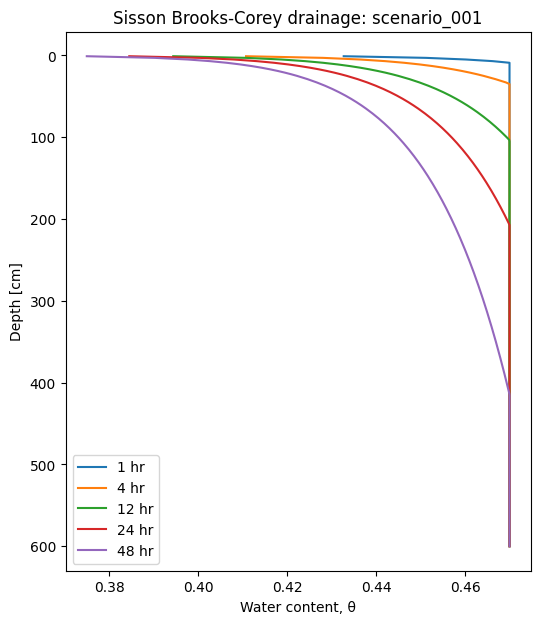

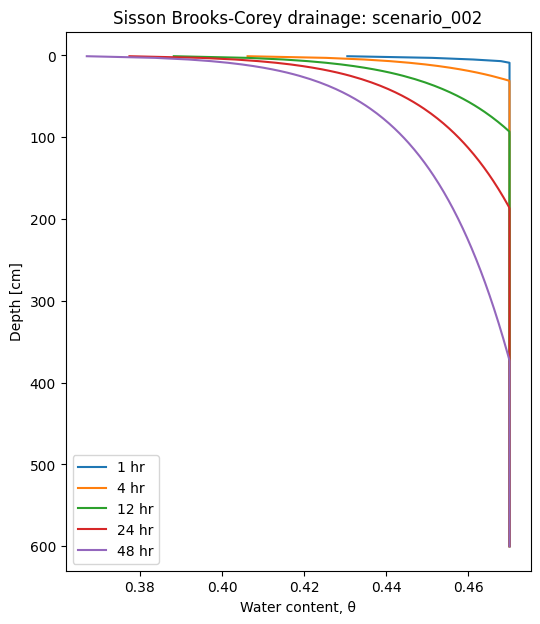

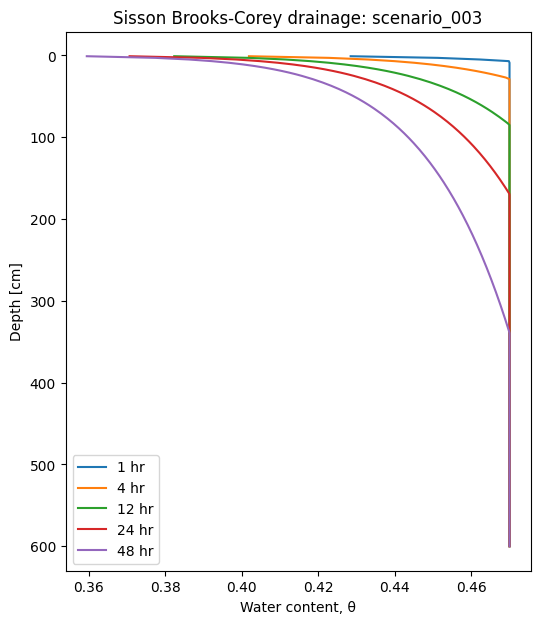

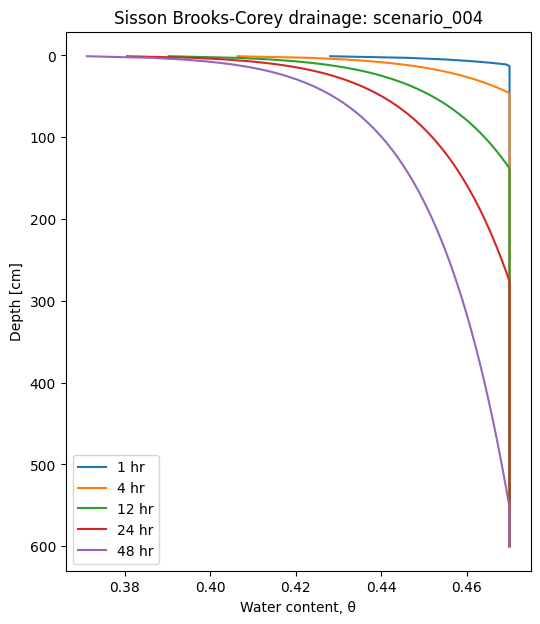

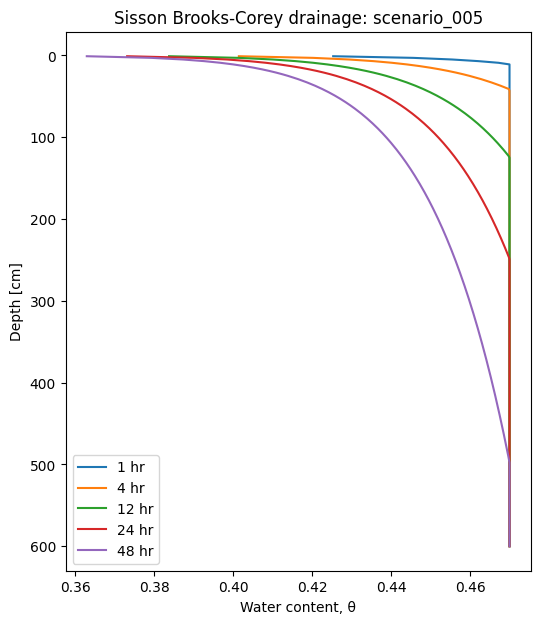

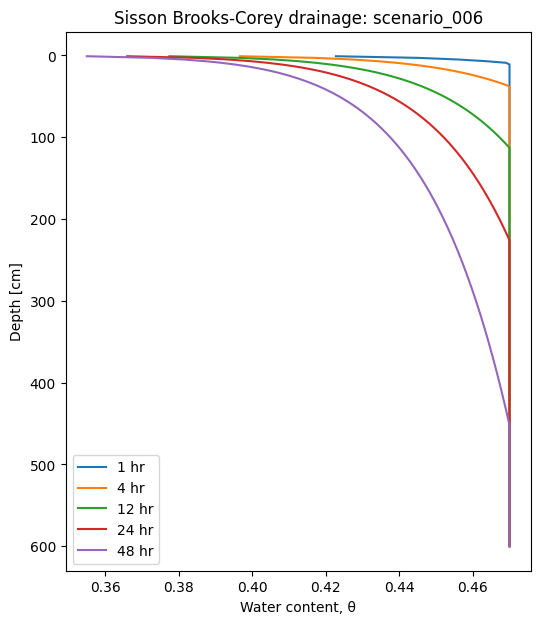

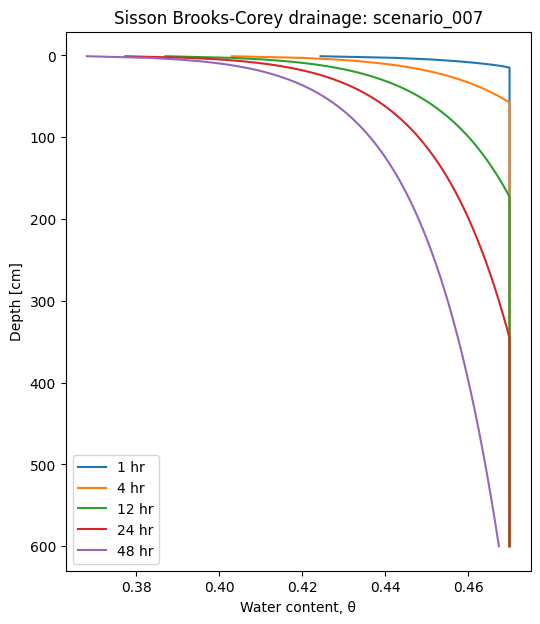

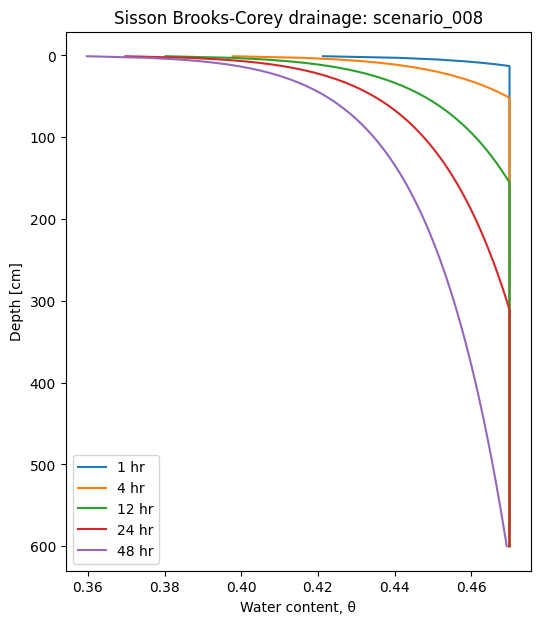

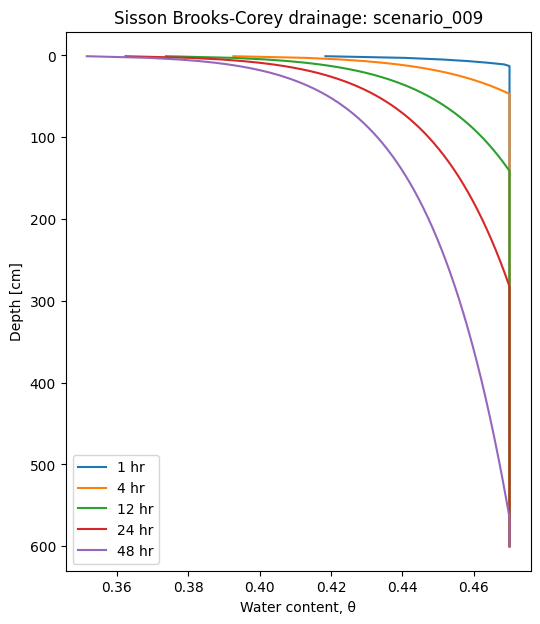

In [156]:
for scenario_name, time_dict in theta_results.items():

    plt.figure(figsize=(6, 7))

    for t, theta in time_dict.items():
        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"Sisson Brooks-Corey drainage: {scenario_name}")
    plt.legend()
    plt.show()

## 3. Plot water content vs Depth over time

### 3.1 For a single soil at a number of time periods

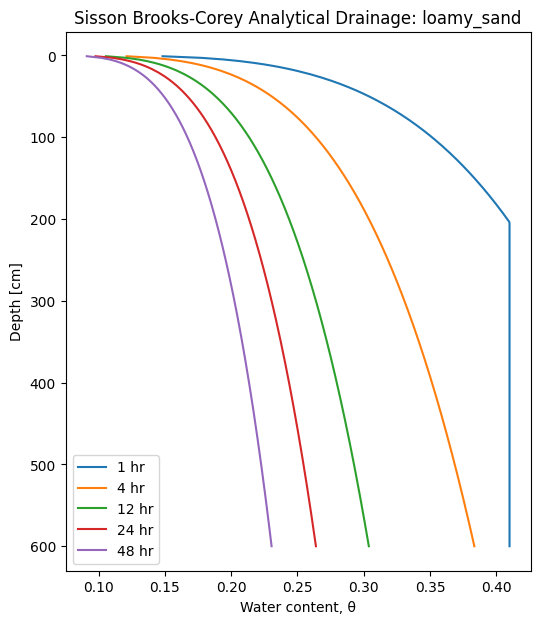

In [157]:
soil_name = "loamy_sand"
preset_soils = known_soils[soil_name]
bc_n = preset_soils["bc_n_fitted"]
q0 = preset_soils["Ks"]

plt.figure(figsize=(6, 7))

for t in times:

    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=preset_soils["theta_r"],
        theta_s=preset_soils["theta_s"],
        Ks=preset_soils["Ks"],
        bc_n=bc_n,
        q0=q0
    )
    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey Analytical Drainage: {soil_name}")
plt.legend()
plt.show()

### 3.2 For all soils in the dictionary over all times

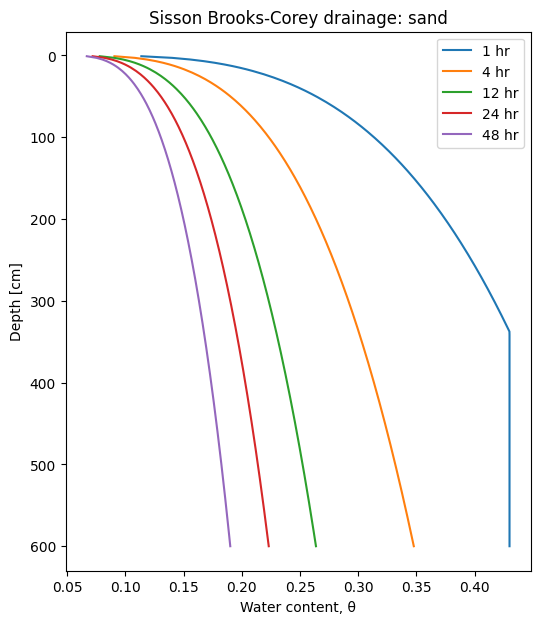

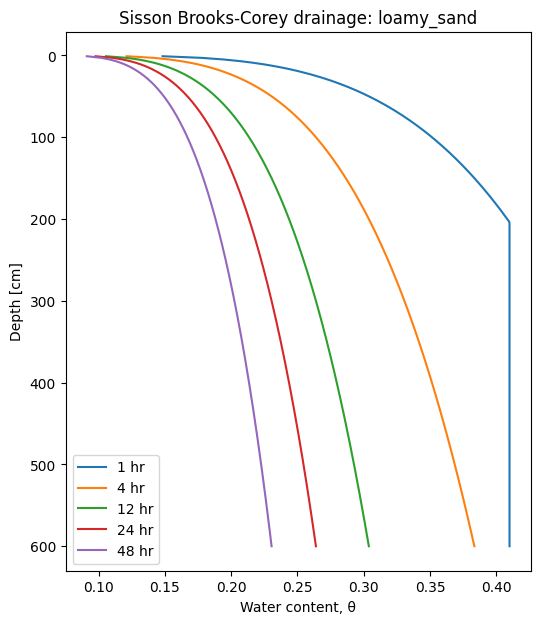

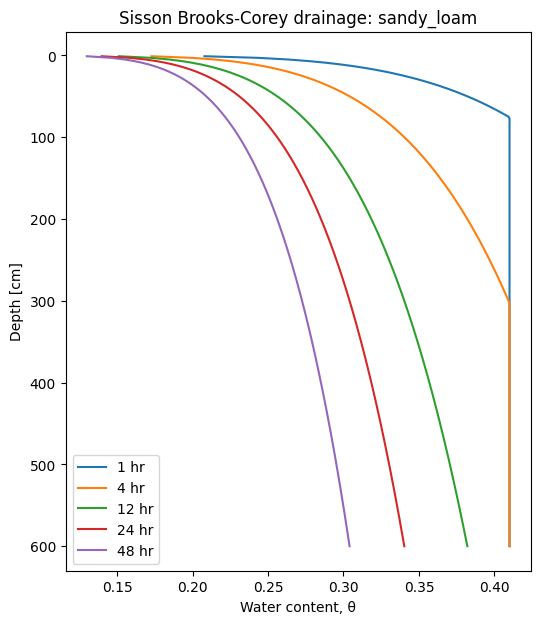

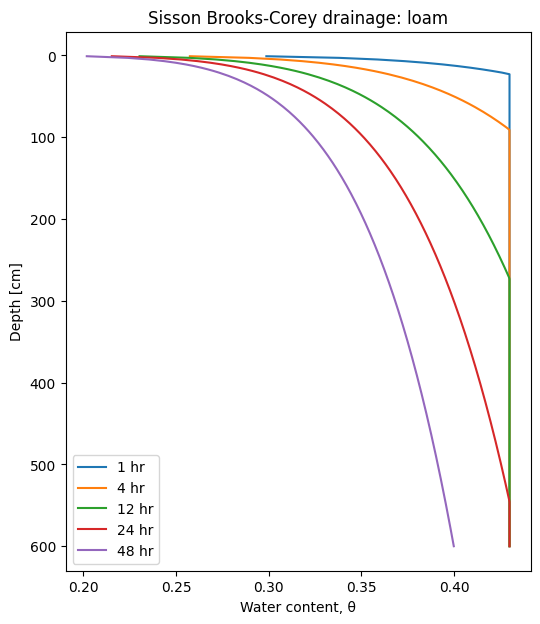

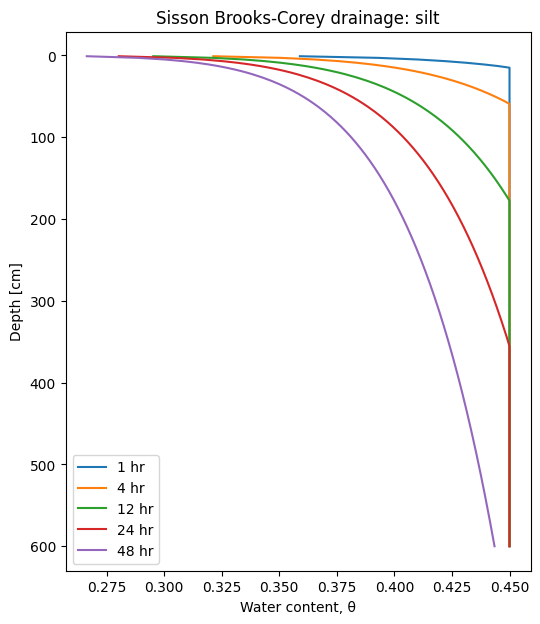

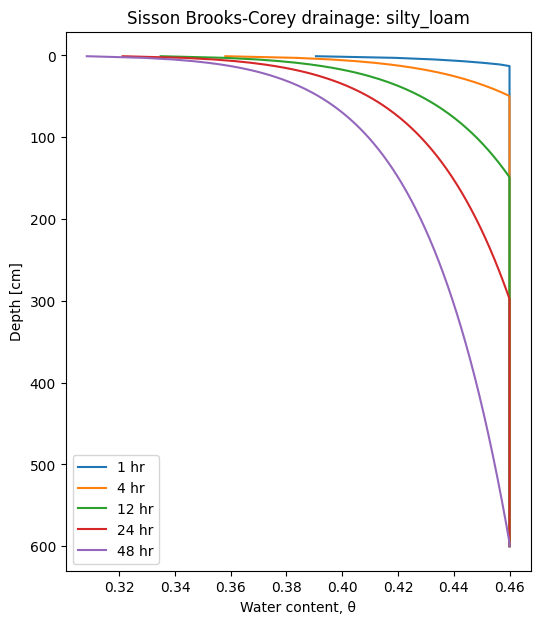

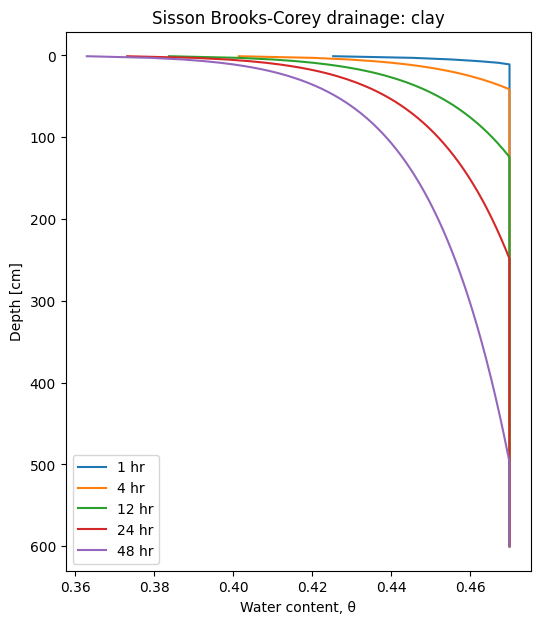

In [158]:
for soil_name, soil in known_soils.items():

    bc_n = soil["bc_n_fitted"]
    q0 = soil["Ks"]

    plt.figure(figsize=(6, 7))

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=soil["theta_r"],
            theta_s=soil["theta_s"],
            Ks=soil["Ks"],
            bc_n=bc_n,
            q0=q0,
            debug=False
        )

        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"Sisson Brooks-Corey drainage: {soil_name}")
    plt.legend()
    plt.show()

## HERE IS THE STOP POINT

In [159]:
def run_analytical_theta_scenario(scenario_name, params, z, times, q0_mode="Ks"):
    """
    Runs the Sisson/Brooks-Corey analytical solution for one parameter set.

    Parameters
    ----------
    scenario_name : str
        Name of the soil/scenario.
    params : dict
        Dictionary containing theta_r, theta_s, Ks, and either bc_n_fitted or bc_n.
    z : array
        Depth array, positive downward.
    times : list or array
        Times to evaluate.
    q0_mode : str
        "Ks" means q0 is set equal to Ks for each scenario.

    Returns
    -------
    theta_results : dict
        Dictionary with one theta profile per time.
    """

    theta_r = params["theta_r"]
    theta_s = params["theta_s"]
    Ks = params["Ks"]

    # Allows you to use either known_soils with bc_n_fitted
    # or ensemble scenarios with bc_n directly
    if "bc_n_fitted" in params:
        bc_n = params["bc_n_fitted"]
    elif "bc_n" in params:
        bc_n = params["bc_n"]
    else:
        bc_n = fit_n_sisson_to_vg_mualem(params["vg_n"])

    if q0_mode == "Ks":
        q0 = Ks
    else:
        q0 = params["q0"]

    theta_results = {}

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=theta_r,
            theta_s=theta_s,
            Ks=Ks,
            bc_n=bc_n,
            q0=q0,
            debug=False
        )

        theta_results[t] = theta

    return theta_results

Use Archies Law to convert water content to electrical conductivity. 

In [160]:
def theta_to_conductivity(theta, sigma_w, m_archie):
    """ convert volumetric water content to bulk electrical conductivity using simplified Archie's law """
    # sigma_bulk = sigma_w * (theta_s ** m_archie) * (sw ** n_archie) [unused parameters theta_s, sw and n_archie]
    sigma_bulk = sigma_w * theta**m_archie
    return sigma_bulk

sigma_matrix = theta_to_conductivity(theta=theta_matrix, sigma_w=sigma_w, m_archie=m_archie)
sigma_matrix.head()

NameError: name 'theta_matrix' is not defined

### 4. SimPEG Forward Model 
#### 4.1 Layered model at 1 time
extract one ec profile at one time step and determine expected TEM response, create a 1D layered TDEM forward model using SimPEG tutorial

In [ ]:
# SimPEG TEM forward model from the electrical conductivity matrix

def run_tem_forward_model_from_sigma(
    layer_conductivities,
    layer_thicknesses,
    height=0.0,
    receiver_orientation="z",
    times=None
):

    if times is None:
        times = np.logspace(-5, -2, 31)

    # Transmitter geometry
    # 20 m x 20 m square loop
    # converted to cm for consistency with HYDRUS output

    loop_size = 2000.0          # cm, equivalent to 20 m
    half_size = loop_size / 2   # loop extends +/-1000 cm from center

    source_vertices = np.array([
        [-half_size, -half_size, height],
        [ half_size, -half_size, height],
        [ half_size,  half_size, height],
        [-half_size,  half_size, height],
        [-half_size, -half_size, height]
    ])

    # Receiver geometry

    receiver_locations = np.array([0.0, 0.0, height])
    receiver_orientation = "z"

    receiver_list = [
        tdem.receivers.PointMagneticFluxDensity(
            receiver_locations,
            times,
            orientation=receiver_orientation
        )
    ]

    # Source and survey

    stepoff_waveform = tdem.sources.StepOffWaveform()

    source_list = [
        tdem.sources.LineCurrent(
            receiver_list=receiver_list,
            location=source_vertices,
            waveform=stepoff_waveform,
        )
    ]

    survey = tdem.Survey(source_list)

    # Conductivity model

    layer_conductivities = np.asarray(layer_conductivities, dtype=float)
    layer_thicknesses = np.asarray(layer_thicknesses, dtype=float)

    n_layers = len(layer_conductivities)

    conductivity_map = maps.IdentityMap(nP=n_layers)

    simulation = tdem.simulation_1d.Simulation1DLayered(
        survey=survey,
        sigmaMap=conductivity_map,
        thicknesses=layer_thicknesses,
    )

    dpred = simulation.dpred(layer_conductivities)

    return times, dpred

### 4.2 Layered model at all times

In [ ]:
# Run TEM forward model for every HYDRUS time

tem_predictions = {}

depth_vector = sigma_matrix.index.to_numpy()
layer_thicknesses = np.abs(np.diff(depth_vector))

for hydrus_time in sigma_matrix.columns:
    layer_conductivities = sigma_matrix[hydrus_time].to_numpy()

    times, response = run_tem_forward_model_from_sigma(
        layer_conductivities=layer_conductivities,
        layer_thicknesses=layer_thicknesses,
        height=10.0
    )

    tem_predictions[hydrus_time] = response

tem_response_matrix = pd.DataFrame(
    tem_predictions,
    index=times
)

tem_response_matrix.index.name = "TEM_time_s"

tem_response_matrix.head()

### 4.3 Plot
#### response shown as TEM response over time as that is how the HYDRUS simulations have been done. Can be adjusted to give a singular response profile if desired

In [ ]:
plt.figure(figsize=(8, 6))

for hydrus_time in tem_response_matrix.columns:
    plt.loglog(
        tem_response_matrix.index,
        np.abs(tem_response_matrix[hydrus_time]),
        label=f"{hydrus_time} hr"
    )

plt.xlabel("Time after shutoff [s]")
plt.ylabel("Predicted magnetic flux density |B| [T]")
plt.title("Predicted TEM responses through HYDRUS time")
plt.legend()
plt.grid(True, which="both")
plt.show()

For now, we are only looking for TDEM Response for clustering 6/19/26

Later... I could convert backwards to the electrical conductivity profile, then the water content profile, then......figure out the vG parameters